# Tuning FLORIS using ModelFit

Demonstrate tuning of FLORIS to the SCADA data using the ModelFit object

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from optuna.visualization.matplotlib import (
    plot_contour,
    plot_slice,
)

from flasc.data_processing.dataframe_manipulations import (
    is_day_or_night,
)
from flasc.model_fitting.cost_library import CostFunctionBase, TurbinePowerMeanAbsoluteError
from flasc.model_fitting.model_fit import ModelFit
from flasc.model_fitting.opt_library import extract_optuna_trial_data, opt_optuna
from flasc.utilities.utilities_examples import load_floris_smarteole

## Parameters

In [2]:
# Number of trials per optimization
n_trials = 20

## Read data and prepare data

Use previously definied 60s data and condition the data as before

In [3]:
# Read in data
root_path = Path.cwd()
f = root_path / "postprocessed" / "df_scada_data_60s_filtered_and_northing_calibrated.pkl"
df_scada = pd.read_pickle(f)

In [4]:
# Add day/night boolean to SCADA data
latitude = 49.8435
longitude = 2.801556

# Compute day/night in default settings and plot
df_scada = is_day_or_night(df_scada, latitude, longitude)

In [5]:
# Limit SCADA data to region of wake steering

# Specify offsets
start_of_offset = 200  # deg
end_of_offset = 240  # deg

# Limit SCADA to this region
df_scada = df_scada[
    (df_scada.wd_smarteole > (start_of_offset - 20))
    & (df_scada.wd_smarteole < (end_of_offset + 20))
]

In [6]:
# Assign wd, ws and pow ref and subset SCADA based on reference variables used
# in the SMARTEOLE wake steering experiment (TODO reference the experiment)
df_scada = df_scada.assign(
    wd=lambda df_: df_["wd_smarteole"],
    ws=lambda df_: df_["ws_smarteole"],
    pow_ref=lambda df_: df_["pow_ref_smarteole"],
).reset_index(drop=True)

## Load FLORIS Model

In [7]:
fm, _ = load_floris_smarteole(wake_model="emgauss")
D = fm.core.farm.rotor_diameters[0]

## Split the data into sub groups

In [8]:
# Split SCADA into baseline and wake steeering (controlled)
df_scada_baseline = df_scada[df_scada.control_mode == "baseline"].reset_index(drop=True).copy()
df_scada_controlled = df_scada[df_scada.control_mode == "controlled"].reset_index(drop=True).copy()

In [9]:
# Further split SCADA into day and night
df_scada_baseline_day = df_scada_baseline[df_scada_baseline.is_day].reset_index(drop=True).copy()
df_scada_baseline_night = df_scada_baseline[~df_scada_baseline.is_day].reset_index(drop=True).copy()
df_scada_controlled_day = (
    df_scada_controlled[df_scada_controlled.is_day].reset_index(drop=True).copy()
)
df_scada_controlled_night = (
    df_scada_controlled[~df_scada_controlled.is_day].reset_index(drop=True).copy()
)

## Tuning recovery on baseline data

The first element of the wake expansion parameter array is named we_1 in this analysis.  It governs the wake expansion in the empirical gaussian model up to the first defined breakpoint (often 10D).  Given the close spacing it is only necessary to tune this parameter.

First define the parameter for model fit

In [10]:
# Just tune the first wake expansion parameter
parameter_list = [
    (
        "wake",
        "wake_velocity_parameters",
        "empirical_gauss",
        "wake_expansion_rates",
    )
]

parameter_name_list = [
    "we_1",
]

parameter_range_list = [
    (0.0, 0.05),
]

parameter_index_list = [0]

## Custom cost function

In [11]:
# ModelFit provides a number of pre-defined cost functions in the cost_library module
# However, there is also flexibility to define custom cost function. Custom cost functions
# should inherit from CostFunctionBase and implement the cost() method.

# In this example, we define a custom cost function that compute the absolute error of the power
# for a single turbine (turbine 004) and use this for model tuning.


class Turbine004PowerErrorAbs(CostFunctionBase):
    """Custom cost function to compute the absolute error of turbine 004 power."""

    def cost(self, df_floris):
        """Compute the absolute error of turbine 004 power."""
        return (self.df_scada["pow_004"] - df_floris["pow_004"]).abs().mean()


# Note that the provided TurbinePowerMeanAbsoluteError cost function can also be used for this
# purpose
cost_function_demo = TurbinePowerMeanAbsoluteError(turbine_power_subset=[4])

# Baseline tuning

Tune we_1 to the best fit for all the baseline data

In [12]:
# We can also optionally df_scada_baseline to the cost function instantiation. We don't need to
# though, since it will be passed within the instantiation of ModelFit.
t004_cost_function = Turbine004PowerErrorAbs()

# Model Fit object
mf = ModelFit(
    df_scada_baseline,
    fm,
    t004_cost_function,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

In [13]:
# Run the optimization for n_trials
opt_result = opt_optuna(mf, timeout=None, n_trials=n_trials)

[I 2025-09-15 09:37:19,926] A new study created in memory with name: ModelFit
[I 2025-09-15 09:37:21,494] Trial 0 finished with value: 147.3166409278423 and parameters: {'we_1': 0.01}. Best is trial 0 with value: 147.3166409278423.
floris.floris_model.FlorisModel WARNING Some velocities at the rotor are negative.
[I 2025-09-15 09:37:23,395] Trial 1 finished with value: 154.85182911860682 and parameters: {'we_1': 0.0004958531938503042}. Best is trial 0 with value: 147.3166409278423.
[I 2025-09-15 09:37:25,303] Trial 2 finished with value: 158.5500115420769 and parameters: {'we_1': 0.04344245871133526}. Best is trial 0 with value: 147.3166409278423.
[I 2025-09-15 09:37:27,266] Trial 3 finished with value: 146.0474656264817 and parameters: {'we_1': 0.013882442555512482}. Best is trial 3 with value: 146.0474656264817.
[I 2025-09-15 09:37:29,191] Trial 4 finished with value: 147.16258395884176 and parameters: {'we_1': 0.02408000417752251}. Best is trial 3 with value: 146.0474656264817.
[I 2

In [14]:
# Print the best result
we_1_baseline = opt_result["optimized_parameter_values"][0]

print(f"Best we_1 from baseline tuning: {we_1_baseline}")

Best we_1 from baseline tuning: 0.0168170410188809


/var/folders/zl/d69s6z796rs4fw08fnxrl0qxydms74/T/ipykernel_80827/2588499832.py:3: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(opt_result["optuna_study"])


<Axes: title={'center': 'Slice Plot'}, xlabel='we_1', ylabel='Objective Value'>

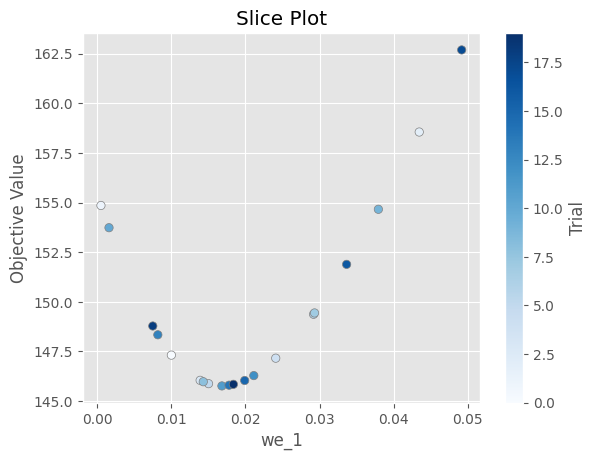

In [15]:
# Use the slice plot provided by optuna to visualize the values of the parameters
# considered within the optimization
plot_slice(opt_result["optuna_study"])

# Tune the recovery to baseline day and night data

Using the data split into day and night results, tune the recovery to each to see how the best fit changes under these different conditions.

#### Daytime result

In [16]:
mf_day = ModelFit(
    df_scada_baseline_day,
    fm,
    t004_cost_function,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

opt_result_day = opt_optuna(mf_day, timeout=None, n_trials=n_trials)

we_1_baseline_day = opt_result_day["optimized_parameter_values"][0]

print(f"Best we_1 for day: {we_1_baseline_day}")

[I 2025-09-15 09:37:58,321] A new study created in memory with name: ModelFit


Cost object already has df_scada assigned. Overwriting.


[I 2025-09-15 09:37:59,579] Trial 0 finished with value: 156.34623364294382 and parameters: {'we_1': 0.01836900578947348}. Best is trial 0 with value: 156.34623364294382.
[I 2025-09-15 09:38:00,646] Trial 1 finished with value: 157.49644104028576 and parameters: {'we_1': 0.028539042108595328}. Best is trial 0 with value: 156.34623364294382.
[I 2025-09-15 09:38:01,719] Trial 2 finished with value: 161.27188988721502 and parameters: {'we_1': 0.03844072292374351}. Best is trial 0 with value: 156.34623364294382.
floris.floris_model.FlorisModel WARNING Some velocities at the rotor are negative.
[I 2025-09-15 09:38:02,807] Trial 3 finished with value: 164.3899421263282 and parameters: {'we_1': 0.0025317934328297543}. Best is trial 0 with value: 156.34623364294382.
[I 2025-09-15 09:38:03,920] Trial 4 finished with value: 156.25039602854434 and parameters: {'we_1': 0.02051302904399372}. Best is trial 4 with value: 156.25039602854434.
[I 2025-09-15 09:38:04,991] Trial 5 finished with value: 156

Best we_1 for day: 0.02051302904399372


#### Night results

In [17]:
mf_night = ModelFit(
    df_scada_baseline_night,
    fm,
    t004_cost_function,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

opt_result_night = opt_optuna(mf_night, timeout=None, n_trials=n_trials)

we_1_baseline_night = opt_result_night["optimized_parameter_values"][0]

print(f"Best we_1 for night: {we_1_baseline_night}")

[I 2025-09-15 09:38:20,343] A new study created in memory with name: ModelFit


Cost object already has df_scada assigned. Overwriting.


[I 2025-09-15 09:38:21,422] Trial 0 finished with value: 152.91184441836586 and parameters: {'we_1': 0.042904268380222446}. Best is trial 0 with value: 152.91184441836586.
floris.floris_model.FlorisModel WARNING Some velocities at the rotor are negative.
[I 2025-09-15 09:38:22,425] Trial 1 finished with value: 142.69683390353217 and parameters: {'we_1': 0.0013622369997475293}. Best is trial 1 with value: 142.69683390353217.
[I 2025-09-15 09:38:23,442] Trial 2 finished with value: 147.0812505226484 and parameters: {'we_1': 0.03637757640035575}. Best is trial 1 with value: 142.69683390353217.
[I 2025-09-15 09:38:24,416] Trial 3 finished with value: 140.49596049232525 and parameters: {'we_1': 0.028099819734273654}. Best is trial 3 with value: 140.49596049232525.
[I 2025-09-15 09:38:25,415] Trial 4 finished with value: 150.53204345013333 and parameters: {'we_1': 0.040269978997943705}. Best is trial 3 with value: 140.49596049232525.
[I 2025-09-15 09:38:26,465] Trial 5 finished with value: 1

Best we_1 for night: 0.014357469585588735


### Comparing the results

Notice the tuning parameters indicate less wake recovery in the night (smaller we_1) and more wake recovery in the day (larger we_1).

In [18]:
# Print a small table with the best parameters
print("Best parameters:")
print(f"All data: {we_1_baseline:.3f}")
print(f"Day data: {we_1_baseline_day:.3f}")
print(f"Night data: {we_1_baseline_night:.3f}")

Best parameters:
All data: 0.017
Day data: 0.021
Night data: 0.014


### Plot comparison

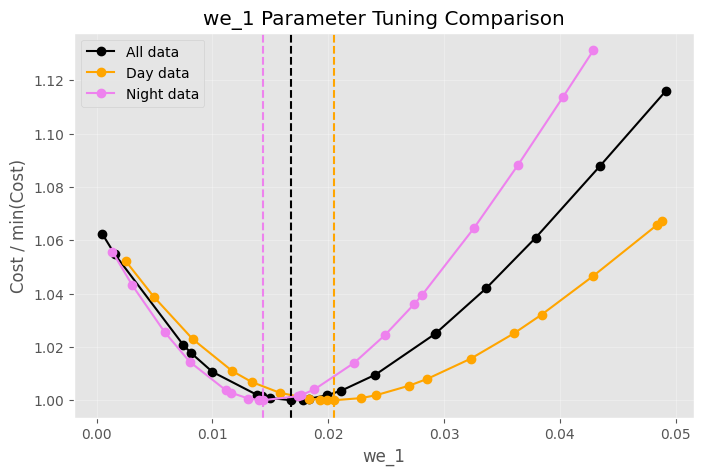

In [19]:
# Compare the results for we_1 in a single plot
fig, ax = plt.subplots(figsize=(8, 5))

# Get data for each study
all_data_params, all_data_costs, best_all_param, best_all_cost = extract_optuna_trial_data(
    opt_result["optuna_study"], "we_1"
)
day_params, day_costs, best_day_param, best_day_cost = extract_optuna_trial_data(
    opt_result_day["optuna_study"], "we_1"
)
night_params, night_costs, best_night_param, best_night_cost = extract_optuna_trial_data(
    opt_result_night["optuna_study"], "we_1"
)

# Create plots
ax.plot(all_data_params, all_data_costs, label="All data", marker="o", color="black")
ax.plot(day_params, day_costs, label="Day data", marker="o", color="orange")
ax.plot(night_params, night_costs, label="Night data", marker="o", color="violet")

ax.axvline(best_all_param, color="black", ls="--")
ax.axvline(best_day_param, color="orange", ls="--")
ax.axvline(best_night_param, color="violet", ls="--")

ax.set_title("we_1 Parameter Tuning Comparison")
ax.set_ylabel("Cost / min(Cost)")
ax.set_xlabel("we_1")
ax.legend()
ax.grid(True, alpha=0.3)

# Tune the deflection gain to the baseline data

The deflection gain in the emgauss model defines the gain in the deflection of the wake at the downstream turbine following a yaw angle misalignment.  A higher gain indicates more deflection of the wake.

## Update the FLORIS model with the best values of we_1 for each case from the baseline data

In [20]:
fm_baseline = fm.copy()
fm_baseline_day = fm.copy()
fm_baseline_night = fm.copy()

fm_baseline.set_param(parameter_list[0], we_1_baseline, 0)
fm_baseline_day.set_param(parameter_list[0], we_1_baseline_day, 0)
fm_baseline_night.set_param(parameter_list[0], we_1_baseline_night, 0)

## Tune the deflection parameter

First define the deflection parameter

In [21]:
# Just tune the first wake expansion parameter
parameter_list = [
    (
        "wake",
        "wake_deflection_parameters",
        "empirical_gauss",
        "horizontal_deflection_gain_D",
    )
]

parameter_name_list = [
    "deflection_gain",
]

parameter_range_list = [
    (0.0, 5.0),
]

parameter_index_list = [None]

## Also define the yaw angles to be resimulated in each case

In [22]:
# Set the yaw angle matrix for when using all the controlled data
yaw_vec = df_scada_controlled.wind_vane_005
yaw_angles_controlled = np.zeros((yaw_vec.shape[0], 7))
yaw_angles_controlled[:, 5] = yaw_vec  # Turbine 005 is the turbine implementing wake steering

# Set the yaw angles for day and night data
yaw_vec_day = df_scada_controlled_day.wind_vane_005
yaw_angles_controlled_day = np.zeros((yaw_vec_day.shape[0], 7))
yaw_angles_controlled_day[:, 5] = yaw_vec_day

yaw_vec_night = df_scada_controlled_night.wind_vane_005
yaw_angles_controlled_night = np.zeros((yaw_vec_night.shape[0], 7))
yaw_angles_controlled_night[:, 5] = yaw_vec_night

## Tune the deflection parameter

In [23]:
# Tune to all controlled data
mf_deflection = ModelFit(
    df_scada_controlled,
    fm_baseline,  # Use the model tuned to all baseline data
    t004_cost_function,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles_controlled,
)

opt_result_deflection = opt_optuna(mf_deflection, timeout=None, n_trials=n_trials)
def_gain = opt_result_deflection["optimized_parameter_values"][0]

[I 2025-09-15 09:38:41,627] A new study created in memory with name: ModelFit


Cost object already has df_scada assigned. Overwriting.


[I 2025-09-15 09:38:43,396] Trial 0 finished with value: 156.17705915506147 and parameters: {'deflection_gain': 3.0}. Best is trial 0 with value: 156.17705915506147.
[I 2025-09-15 09:38:45,216] Trial 1 finished with value: 156.15727664246447 and parameters: {'deflection_gain': 0.5978842667769285}. Best is trial 1 with value: 156.15727664246447.
[I 2025-09-15 09:38:47,049] Trial 2 finished with value: 156.26411842323694 and parameters: {'deflection_gain': 3.049247755303089}. Best is trial 1 with value: 156.15727664246447.
[I 2025-09-15 09:38:48,860] Trial 3 finished with value: 159.61140546461354 and parameters: {'deflection_gain': 4.370087375604924}. Best is trial 1 with value: 156.15727664246447.
[I 2025-09-15 09:38:50,677] Trial 4 finished with value: 155.12664008274623 and parameters: {'deflection_gain': 1.8996118334784184}. Best is trial 4 with value: 155.12664008274623.
[I 2025-09-15 09:38:52,466] Trial 5 finished with value: 155.57069083104608 and parameters: {'deflection_gain': 

In [24]:
# Tune to the day data
mf_day = ModelFit(
    df_scada_controlled_day,
    fm_baseline_day,  # Use the model tuned to day-time baseline data
    t004_cost_function,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles_controlled_day,
)

opt_result_deflection_day = opt_optuna(mf_day, timeout=None, n_trials=n_trials)
def_gain_day = opt_result_deflection_day["optimized_parameter_values"][0]

[I 2025-09-15 09:39:17,849] A new study created in memory with name: ModelFit


Cost object already has df_scada assigned. Overwriting.


[I 2025-09-15 09:39:18,804] Trial 0 finished with value: 173.2959494567273 and parameters: {'deflection_gain': 3.0}. Best is trial 0 with value: 173.2959494567273.
[I 2025-09-15 09:39:19,736] Trial 1 finished with value: 172.59074272404135 and parameters: {'deflection_gain': 2.743170066924105}. Best is trial 1 with value: 172.59074272404135.
[I 2025-09-15 09:39:20,649] Trial 2 finished with value: 174.15138259176004 and parameters: {'deflection_gain': 3.2839420390158214}. Best is trial 1 with value: 172.59074272404135.
[I 2025-09-15 09:39:21,708] Trial 3 finished with value: 172.92507447188362 and parameters: {'deflection_gain': 2.8675370239995726}. Best is trial 1 with value: 172.59074272404135.
[I 2025-09-15 09:39:22,639] Trial 4 finished with value: 173.95517815563494 and parameters: {'deflection_gain': 3.220839036201478}. Best is trial 1 with value: 172.59074272404135.
[I 2025-09-15 09:39:23,628] Trial 5 finished with value: 170.32451271696348 and parameters: {'deflection_gain': 1.

In [25]:
# Tune to the night data
mf_night = ModelFit(
    df_scada_controlled_night,
    fm_baseline_night,  # Use the model tuned to night-time baseline data
    t004_cost_function,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles_controlled_night,
)
opt_result_deflection_night = opt_optuna(mf_night, timeout=None, n_trials=n_trials)
def_gain_night = opt_result_deflection_night["optimized_parameter_values"][0]

[I 2025-09-15 09:39:36,642] A new study created in memory with name: ModelFit


Cost object already has df_scada assigned. Overwriting.


[I 2025-09-15 09:39:37,615] Trial 0 finished with value: 140.1960859678203 and parameters: {'deflection_gain': 3.0}. Best is trial 0 with value: 140.1960859678203.
[I 2025-09-15 09:39:38,547] Trial 1 finished with value: 140.1843428947465 and parameters: {'deflection_gain': 2.981308462311717}. Best is trial 1 with value: 140.1843428947465.
[I 2025-09-15 09:39:39,570] Trial 2 finished with value: 142.55625488464923 and parameters: {'deflection_gain': 1.079297590160015}. Best is trial 1 with value: 140.1843428947465.
[I 2025-09-15 09:39:40,507] Trial 3 finished with value: 140.19760500017213 and parameters: {'deflection_gain': 3.0023592969438995}. Best is trial 1 with value: 140.1843428947465.
[I 2025-09-15 09:39:41,478] Trial 4 finished with value: 141.90416474490556 and parameters: {'deflection_gain': 4.115983468127084}. Best is trial 1 with value: 140.1843428947465.
[I 2025-09-15 09:39:42,570] Trial 5 finished with value: 145.10056445873875 and parameters: {'deflection_gain': 0.317072

# Compare the results for the deflection gain

Results indicate that the wake deflection gain is larger at night than at day.  

In [26]:
# Print a table with the best parameters
print("Best parameters:")
print(f"All data: {def_gain:.3f}")
print(f"Day data: {def_gain_day:.3f}")
print(f"Night data: {def_gain_night:.3f}")

Best parameters:
All data: 1.738
Day data: 0.311
Night data: 2.672


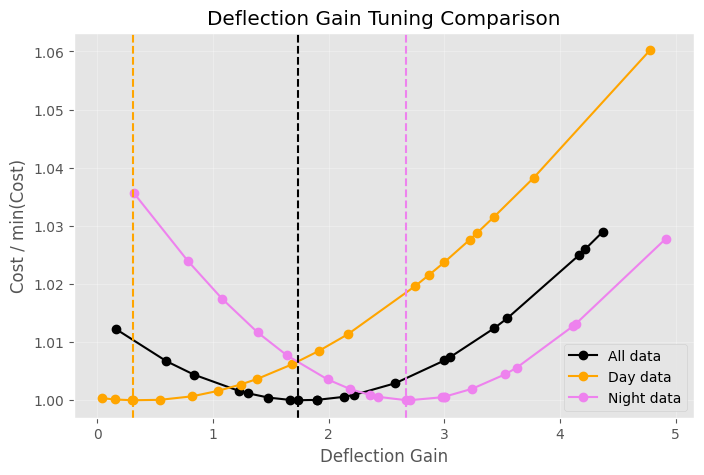

In [27]:
# Make comparison plot of the results

# Compare the results for deflection gain in a single plot
fig, ax = plt.subplots(figsize=(8, 5))

# Get data for each study
all_data_params, all_data_costs, best_all_param, best_all_cost = extract_optuna_trial_data(
    opt_result_deflection["optuna_study"], "deflection_gain"
)
day_params, day_costs, best_day_param, best_day_cost = extract_optuna_trial_data(
    opt_result_deflection_day["optuna_study"], "deflection_gain"
)
night_params, night_costs, best_night_param, best_night_cost = extract_optuna_trial_data(
    opt_result_deflection_night["optuna_study"], "deflection_gain"
)

# Create plots
ax.plot(all_data_params, all_data_costs, label="All data", marker="o", color="black")
ax.plot(day_params, day_costs, label="Day data", marker="o", color="orange")
ax.plot(night_params, night_costs, label="Night data", marker="o", color="violet")

ax.axvline(best_all_param, color="black", ls="--")
ax.axvline(best_day_param, color="orange", ls="--")
ax.axvline(best_night_param, color="violet", ls="--")

ax.set_title("Deflection Gain Tuning Comparison")
ax.set_ylabel("Cost / min(Cost)")
ax.set_xlabel("Deflection Gain")
ax.legend()
ax.grid(True, alpha=0.3)

# Simultaneously tune the we_1 and deflection gain parameters

As a final analysis, see what results would have been for all data case if we_1 and deflection were tuned simulaneously to the data

Note results would not be expected to be exactly the same because the data used in training is now not the same (instead of tuning expansion to baseline data and deflection_gain to controlled data, we are tuning both to all data)

In [28]:
# Redo parameter list to include both we_1 and deflection_gain
parameter_list = [
    (
        "wake",
        "wake_velocity_parameters",
        "empirical_gauss",
        "wake_expansion_rates",
    ),
    (
        "wake",
        "wake_deflection_parameters",
        "empirical_gauss",
        "horizontal_deflection_gain_D",
    ),
]

parameter_name_list = [
    "we_1",
    "deflection_gain",
]

parameter_range_list = [
    (0.0, 0.05),
    (0.0, 5.0),
]

parameter_index_list = [0, None]

In [29]:
# Redo yaw angle matrix to all data
yaw_vec = df_scada.wind_vane_005
yaw_angles_all = np.zeros((yaw_vec.shape[0], 7))
yaw_angles_all[:, 5] = yaw_vec

In [30]:
mf_simultaneous = ModelFit(
    df_scada,
    fm,
    t004_cost_function,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles_all,
)

# Double the number of trials since tuning 2 parameters
opt_result_simultaneous = opt_optuna(mf_simultaneous, timeout=None, n_trials=n_trials * 2)

[I 2025-09-15 09:39:56,599] A new study created in memory with name: ModelFit


Cost object already has df_scada assigned. Overwriting.


[I 2025-09-15 09:40:00,493] Trial 0 finished with value: 155.25876129494173 and parameters: {'we_1': 0.027422311575010155, 'deflection_gain': 3.0}. Best is trial 0 with value: 155.25876129494173.
[I 2025-09-15 09:40:05,448] Trial 1 finished with value: 151.5032527786563 and parameters: {'we_1': 0.018807122096767673, 'deflection_gain': 0.9970356480769443}. Best is trial 1 with value: 151.5032527786563.
[I 2025-09-15 09:40:10,086] Trial 2 finished with value: 152.79551251384316 and parameters: {'we_1': 0.02411221036275259, 'deflection_gain': 1.5068449964624993}. Best is trial 1 with value: 151.5032527786563.
[I 2025-09-15 09:40:14,773] Trial 3 finished with value: 156.9870091495833 and parameters: {'we_1': 0.032081942449144, 'deflection_gain': 0.13687779319699}. Best is trial 1 with value: 151.5032527786563.
[I 2025-09-15 09:40:19,552] Trial 4 finished with value: 152.77698924914648 and parameters: {'we_1': 0.01911841159509305, 'deflection_gain': 3.1991760016016664}. Best is trial 1 with

/var/folders/zl/d69s6z796rs4fw08fnxrl0qxydms74/T/ipykernel_80827/1680281793.py:2: ExperimentalWarning: plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  plot_contour(opt_result_simultaneous["optuna_study"])
[W 2025-09-15 09:43:03,539] Output figures of this Matplotlib-based `plot_contour` function would be different from those of the Plotly-based `plot_contour`.


<Axes: title={'center': 'Contour Plot'}, xlabel='deflection_gain', ylabel='we_1'>

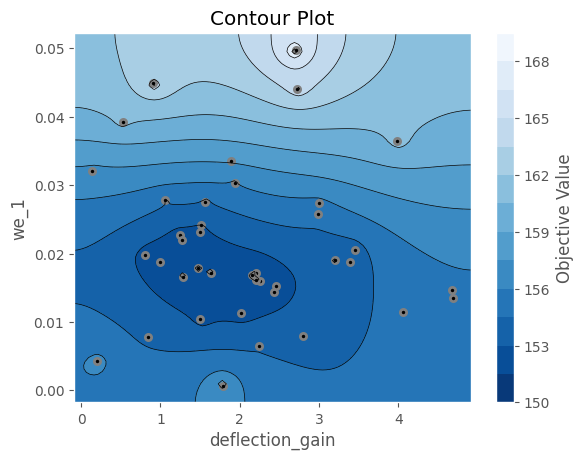

In [31]:
# Show the contour plot using the study object
plot_contour(opt_result_simultaneous["optuna_study"])

In [32]:
# Get the best parameters
we_1_simultaneous = opt_result_simultaneous["optimized_parameter_values"][0]
def_gain_simultaneous = opt_result_simultaneous["optimized_parameter_values"][1]


# Compare to the values computed sequentially
print("Sequential tuning results:")
print(f"Sequential tuning: {we_1_baseline:.3f}, {def_gain:.3f}")
print(f"Simultaneous tuning: {we_1_simultaneous:.3f}, {def_gain_simultaneous:.3f}")

Sequential tuning results:
Sequential tuning: 0.017, 1.738
Simultaneous tuning: 0.017, 1.633
